# V-JEPA World Model Pre-Training at Scale with Ray on Anyscale

## TLDR

You pre-train a V-JEPA world model on multi-camera robotics video using **Ray Data** for streaming preprocessing and **Ray Train** for distributed multi-GPU training on **Anyscale**. The model learns to predict future visual representations in latent space (not pixels) through self-supervised masking. After pre-training, you adapt the model on held-out data using the same `TorchTrainer` API to demonstrate a complete pretrain-to-deployment pipeline. The infrastructure patterns here apply to any world model architecture, not just V-JEPA.

**The focus of this tutorial is Ray.** V-JEPA is the workload. The point here is to show how Ray Data and Ray Train handle the hard infrastructure problems, streaming preprocessing over large video datasets, distributed multi-GPU training, fault-tolerant checkpointing, and seamless scaling, so you can swap in any model architecture and focus on the science instead of the plumbing.



## Introduction

World models are systems that learn to predict what happens next from raw sensory data and are emerging as a critical capability for the next generation of robotics. A robot that can predict "if I push this cup, it will slide left" can plan actions, evaluate alternatives, and adapt to new environments without additional demonstrations. This is why robotics companies are investing heavily in world model research. It promises robots that generalize rather than memorize.

The key insight driving modern world models is to **predict in latent space, not pixel space**. Reconstructing raw pixels is expensive, noisy, and wastes model capacity on irrelevant visual detail (shadows, textures, lighting). Instead, the model learns compressed representations of the world and predicts how those representations evolve over time. This idea appears across many recent architectures, from video prediction models to latent dynamics models to joint-embedding approaches.

In this notebook, we use **V-JEPA (Video Joint-Embedding Predictive Architecture)** as a concrete, working implementation of a latent-space world model. V-JEPA masks large spacetime regions of a video and trains a model to predict the masked representations from the visible ones. As such, there is no decoder, no pixel loss, and no negative pairs. We chose V-JEPA because it cleanly demonstrates the core ideas (latent prediction, self-supervised learning from video, online adaptation) while being tractable for a tutorial. The **Ray on Anyscale infrastructure patterns you learn here apply equally to any world model architecture**, whether your team is building on V-JEPA, Genie, UniSim, DIAMOND, or a custom approach.

Training world models on multi-camera robotics video introduces real distributed systems challenges:

- **Streaming video data** from multi-camera setups is large and must be preprocessed into temporal windows on-the-fly, not loaded entirely into memory.
- **Spacetime masking and dual encoders** (context + EMA target) create non-trivial memory and synchronization requirements across GPUs.
- **Online adaptation** (updating a pre-trained model on new environments) requires the same distributed infrastructure but with different data and learning rates.
- **Fault tolerance and checkpointing** are essential when training runs span hours or days on GPU clusters.

This notebook shows how **Ray on Anyscale** handles all of this:
- **Ray Data** streams and preprocesses multi-camera video into temporal windows on CPUs, feeding GPUs without memory bottlenecks.
- **Ray Train** wraps PyTorch DDP for multi-GPU training with automatic checkpointing, fault tolerance, and dataset sharding. The same code scales from 2 GPUs to 64+ by changing one config line. Here that line reads the cluster, so 2 or 4 GPUs need no edit at all.
- **Anyscale** provides the managed infrastructure: GPU cluster orchestration, shared cluster storage for checkpoints and datasets, and environment management so you focus on the model, not the ops.

You use the **Functional Manipulation Benchmark (FMB)** dataset, which provides multi-camera video of robotic manipulation tasks.

---

## Key concepts used in this notebook

A quick reference for concepts that appear throughout. If you already know these, skip ahead.

**Ray Data** is Ray's library for distributed data processing. It streams data through a pipeline of transformations without loading the full dataset into memory. In this notebook, Ray Data reads video frames from disk, groups them into temporal windows, and feeds them to GPU workers. The key API is `map_batches()`, which applies a Python function to chunks of data in parallel across CPUs.

**Ray Train** is Ray's library for distributed model training. It wraps PyTorch DDP so you write a normal training loop function and Ray handles multi-GPU coordination: launching workers, syncing gradients, sharding data, saving checkpoints, and restarting on failure. The key APIs are `TorchTrainer` (the launcher), `prepare_model()` (DDP wrapping), and `train.report()` (metric/checkpoint reporting).

**EMA (Exponential Moving Average)** is a technique where one model (the "target") is updated as a slow-moving average of another (the "online" model): `target = 0.996 * target + 0.004 * online`. This provides stable prediction targets for self-supervised learning. Without it, both models can collapse to trivial constant outputs.

**GradScaler** is PyTorch's tool for stable mixed-precision (FP16) training. FP16 is faster but can produce inf/NaN gradients. GradScaler scales the loss up before backward (to preserve small gradients in FP16), then scales gradients back down before the optimizer step. If gradients are still inf/NaN, it **skips the optimizer step entirely**. This matters because you must also skip the EMA update when the step is skipped.

**DDP (DistributedDataParallel)** runs copies of the same model on multiple GPUs. After each backward pass, DDP averages gradients across all GPUs so every copy stays in sync. Each GPU processes a different shard of the data, so you get near-linear speedup with more GPUs.

---

## What you will learn

By the end of this notebook, you will be able to:

- **Stream multi-camera robotics video** into temporal windows using **Ray Data** with `read_lerobot` and `map_batches`
- **Train a world model** across multiple GPUs using **Ray Train** with DDP, FP16 mixed precision, and EMA target encoder updates
- **Add checkpointing and fault tolerance** using Ray Train's `FailureConfig` for production-grade training
- **Run distributed online adaptation** on held-out data, loading a pre-trained checkpoint and adapting across workers in parallel
- **Stage datasets on Anyscale cluster storage** from S3, creating separate pretrain/adaptation subsets
- Build a **ViT-Small encoder** with factored spacetime positional embeddings for video
- Implement **V-JEPA's spacetime tube masking** and EMA target encoder for collapse-free self-supervised learning
- Add **action and state conditioning** to make a world model dynamics-aware for robotics

---

## Why Ray on Anyscale for world model training?

World model training sits at the intersection of large-scale data processing and distributed GPU training. Most frameworks handle one well but not both. Ray is designed for exactly this:

| Challenge | Without Ray | With Ray on Anyscale |
|---|---|---|
| Multi-camera video preprocessing | Custom data loaders, memory pressure | **Ray Data** streams and preprocesses on CPUs, feeds GPUs via `iter_torch_batches` |
| Multi-GPU DDP | Manual process spawning, device management | **Ray Train** `TorchTrainer` + `prepare_model()`; change `num_workers` to scale |
| Checkpointing | Filesystem management, rank coordination | **Ray Train** handles it: save on rank 0, auto-restore on resume |
| Fault tolerance | Write your own retry logic | `FailureConfig(max_failures=1)` gives automatic restart from last checkpoint |
| Dataset staging | Manual S3 sync, path management | **Anyscale cluster storage:** shared filesystem visible to all workers |
| Scaling from prototype to production | Rewrite data pipeline, change training harness | Same code, different config: 2 GPUs → 64 GPUs |

The two-phase structure of this notebook (pre-training → online adaptation) uses the **same** `TorchTrainer` API for both phases, demonstrating that Ray Train is a general-purpose distributed training framework, not a single-use wrapper. Swap V-JEPA for your own world model architecture and the infrastructure code stays the same.

---

## Why world models matter for robotics

Robotics companies are converging on world models as a path to more capable, generalizable robots:

- **Planning**: A robot with a world model can mentally simulate action sequences and choose the best one before moving, which is model-predictive control in learned latent space.
- **Sim-to-real transfer**: World models trained on real video learn the visual and physical regularities that simulators approximate poorly (deformable objects, liquids, contact dynamics).
- **Data efficiency**: Rather than collecting demonstrations for every new task, a world model pre-trained on diverse video can adapt to new tasks with minimal additional data.
- **Online adaptation**: When deployed in a new environment, a world model can continuously improve by comparing its predictions to reality, the "predict → observe → update" loop demonstrated in Phase 2 of this notebook.

The specific architecture (V-JEPA, diffusion-based models, autoregressive video prediction, or something not yet invented) matters less than the infrastructure patterns for training and adapting these models at scale. That is what this notebook teaches.

---

## How V-JEPA works

V-JEPA is a self-supervised approach to learning latent-space world models from video. We use it here because it cleanly implements the core ideas and is well-suited to demonstrate distributed training patterns.

```
Input video: 8 frames x 64 spatial patches = 512 spacetime tokens per camera

Step 1: Mask 75% of spacetime tokens (tube masking)
┌──────────────────────────────────┐
│ ████░░██░░████░░██░░████░░██░░░░ │  ██ = masked (75%)
│ ████░░██░░████░░██░░████░░██░░░░ │  ░░ = visible (25%)
│ ████░░██░░████░░██░░████░░██░░░░ │
│ ████░░██░░████░░██░░████░░██░░░░ │  (same spatial positions
│ ████░░██░░████░░██░░████░░██░░░░ │   masked across time =
│ ████░░██░░████░░██░░████░░██░░░░ │   "tube" masking)
│ ████░░██░░████░░██░░████░░██░░░░ │
│ ████░░██░░████░░██░░████░░██░░░░ │
└──────────────────────────────────┘
  t=1  t=2  t=3  t=4  t=5  t=6  t=7  t=8

Step 2: Encode
  Context encoder (trainable ViT)  →  processes visible patches only
  Target encoder  (EMA, no grad)   →  processes ALL patches

Step 3: Predict
  Predictor (small Transformer):
    Input:  context encoder output + learned [MASK] tokens + actions + state
    Output: predicted representations at masked positions

Step 4: Loss
  MSE between predictor output and stop-gradiented target output
  (only at masked positions)

Step 5: Update
  optimizer.step()  →  update context encoder + predictor
  EMA update        →  target_params ← 0.996 * target_params + 0.004 * online_params
```

---

## Training objective

Given a video with spacetime patches $\{p_1, \ldots, p_N\}$, split into visible set $\mathcal{V}$ and masked set $\mathcal{M}$:

$$\mathcal{L} = \frac{1}{|\mathcal{M}|} \sum_{i \in \mathcal{M}} \| f_\theta(\{z^{\text{ctx}}_j\}_{j \in \mathcal{V}}, a_{1:T})_i - \text{sg}(z^{\text{tgt}}_i) \|^2$$

where $z^{\text{ctx}} = \text{ContextEnc}(p_j)$ for visible patches, $z^{\text{tgt}} = \text{TargetEnc}(p_i)$ for all patches, and $\text{sg}(\cdot)$ is the stop-gradient operator.

After each optimizer step:
$$\theta_{\text{target}} \leftarrow \tau \cdot \theta_{\text{target}} + (1 - \tau) \cdot \theta_{\text{online}}, \quad \tau = 0.996$$

---

## Robotics extensions

Standard V-JEPA processes single videos for recognition tasks. This notebook extends it for robotics:

- **Multi-camera (4 views)**: Each camera is processed independently through a shared ViT encoder. This captures the multi-viewpoint structure of robotics setups without quadrupling the token count in attention.
- **Action conditioning (7-d)**: Robot actions are projected and added to predictor tokens, making predictions dynamics-aware ("given this action, what should the masked region look like?").
- **State conditioning (8-d)**: Proprioceptive state provides embodiment context.
- **Online adaptation**: After pre-training, the model adapts to new environments by continuously updating on prediction errors from real observations, distributed across a worker fleet via Ray Train.

---

## Architecture overview

```
For each of 4 cameras:
    Raw frames (B, T, 128, 128, 3)
              |
    [Patch Embed: Conv2d 16x16]  →  (B, T, 64, 384)
              |
    [+ Spatial pos embed + Temporal pos embed]
              |
    [Flatten to spacetime tokens]  →  (B, T*64, 384)
              |
    ┌─────────┴─────────┐
    │                    │
[Visible only]     [All patches]
    │                    │
[Context Encoder]  [Target Encoder]
  (trainable         (EMA, no grad,
   ViT-Small)         same ViT-Small)
    │                    │
    └────────┬───────────┘
             │
    [Predictor Transformer]
    (visible reps + [MASK] tokens
     + action proj + state proj
     + positional embeddings)
             │
    [Linear head → VIT_DIM]
             │
    predicted reps at masked positions
             │
    MSE loss vs stop-grad target reps
```

---

## How this scales on Anyscale

This tutorial runs on **whatever GPUs the cluster has** (2 or 4 in this course) with 50 episodes per phase. The same code scales directly on Anyscale. Change the config, not the code:

| Scale lever | Tutorial | Production on Anyscale |
|---|---|---|
| Episodes | 50 + 50 | 10,000+ |
| Workers | 2 | 8-64+ |
| GPU type | any ≥16 GB | A100/H100 |
| ViT depth | 6 layers | 12-24 layers |
| Context length | 8 frames | 16-64 frames |
| Image resolution | 128x128 | 224x224+ |
| EMA schedule | Fixed 0.996 | Cosine 0.996 → 1.0 |

Anyscale manages the cluster scaling, GPU scheduling, and shared storage, so you adjust `ScalingConfig(num_workers=N)` and the platform handles the rest.

## Where this fits in the course

In notebooks 01-03 you streamed robotics data, fine-tuned a VLA policy, and used a *simulator* to evaluate it and generate new training data. This notebook flips that idea: instead of *using* a simulator, you **learn one**. A world model is, in effect, a learned simulator -- it predicts how the world evolves in a latent space -- and once trained it can drive planning, evaluation, and data generation without a hand-built physics engine.

The infrastructure is the stack you already know: the shared `lerobot_datasource` from notebook 01 streams the multi-camera video, and the `TorchTrainer` pattern from notebook 02 (`prepare_model`, `train.report`, `FailureConfig`, `ScalingConfig`) drives both the distributed pre-training **and** the online-adaptation phase here. Only the model and the data change.

## Cell 1: Environment check and imports

Verify the cluster environment and import the libraries you need. The LeRobot datasource (`tools/lerobot_datasource.py`) is a single-file Ray Data source for LeRobot v3 datasets that ships alongside this notebook.

In [1]:
import os
import sys
import time
import tempfile
import pickle
import copy
import math

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.distributed as dist

import ray
from ray import train
from ray.train import ScalingConfig, RunConfig, FailureConfig, Checkpoint
from ray.train.torch import TorchTrainer, prepare_model

from tools.lerobot_datasource import read_lerobot, Partitioning

print(f"Python:      {sys.version.split()[0]}")
print(f"PyTorch:     {torch.__version__}")
print(f"Ray:         {ray.__version__}")

Python:      3.11.14
PyTorch:     2.10.0+cu128
Ray:         2.53.0


## Cell 2: Ray initialization

Connect to the Ray cluster. On **Anyscale**, `ray.init(address="auto")` connects to the managed cluster that is already running.Anyscale handles node provisioning, GPU scheduling, and cluster lifecycle. Locally, this falls back to starting a single-node cluster for development.

This single line is all the infrastructure setup you need. Once connected, `ray.cluster_resources()` shows the GPUs and CPUs available. These are the resources that Ray Data and Ray Train will use for data preprocessing and distributed training.

In [2]:
try:
    ray.init(address="auto", ignore_reinit_error=True)
except ConnectionError:
    ray.init(ignore_reinit_error=True)

from tools import cluster
cluster.describe()

# One DDP worker per GPU, derived from the live cluster: 2 GPUs on two nodes and
# 4 GPUs on one g6.12xlarge both work without editing anything below.
NUM_TRAIN_WORKERS = cluster.train_workers()

2026-08-18 16:54:20,569	INFO worker.py:1821 -- Connecting to existing Ray cluster at address: 10.0.210.111:6379...
2026-08-18 16:54:20,582	INFO worker.py:1998 -- Connected to Ray cluster. View the dashboard at https://session-brny5cdu3znpxlisuj4ge511jv.i.anyscaleuserdata.com 
2026-08-18 16:54:20,621	INFO packaging.py:463 -- Pushing file package 'gcs://_ray_pkg_9bb2cd32f8cb7cc1e2bf84a0cb59070e7a493345.zip' (14.54MiB) to Ray cluster...
2026-08-18 16:54:20,677	INFO packaging.py:476 -- Successfully pushed file package 'gcs://_ray_pkg_9bb2cd32f8cb7cc1e2bf84a0cb59070e7a493345.zip'.


Cluster: 4 GPU(s) (L4) across 1 GPU node(s), 48 CPUs total
  ip-10-0-237-165: 4 x L4, 48 CPU, 115 GiB Ray memory
Derived: train workers = 4, sim workers (nb03) = 1


/home/ray/anaconda3/lib/python3.11/site-packages/ray/_private/worker.py:2046: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


## Cell 3: Configuration

All tunable parameters in one place. The key design decisions:

- **`NUM_PRETRAIN_EPISODES = 50`**, **`NUM_ADAPT_EPISODES = 50`**: Separate datasets for pre-training and online adaptation. In production, pre-training uses your historical data; adaptation uses new incoming data from deployed robots.
- **`CONTEXT_LEN = 8`**: The model sees 8 frames of history. Each frame produces 64 patches, so the ViT processes 512 spacetime tokens per camera. We keep this short to keep attention costs manageable as attention is $O(n^2)$ in the number of tokens.
- **`BATCH_SIZE = 8`**: Per-worker batch size. With 2 workers, effective (global) batch is 16. Constrained by ViT activation memory at 512 tokens per camera.
- **`MASK_RATIO = 0.75`**: 75% of spacetime patches are masked, following V-JEPA's aggressive masking strategy. Higher masking forces the model to learn more abstract, predictive representations rather than relying on local interpolation.
- **`EMA_MOMENTUM = 0.996`**: Target encoder updates slowly (see "Key concepts" in the introduction). This prevents representation collapse. If the target moved too fast (low momentum), both encoders could converge to trivial constant outputs. Production systems use a cosine schedule from 0.996 to 1.0.
- **`VIT_LAYERS = 6`**: A 6-layer ViT-Small encoder. Standard V-JEPA uses ViT-L (24 layers) or ViT-H (32 layers). We use 6 layers for tutorial speed as the infrastructure patterns are identical regardless of depth.
- **`PRED_LAYERS = 2`**: The predictor is intentionally smaller than the encoder. This forces the encoder to learn good representations rather than letting the predictor compensate for a weak encoder.

In [3]:
# ── Data paths ──
S3_BUCKET = "s3://anyscale-public-materials-use2/lerobot/lerobot/fmb"
LOCAL_FULL_DIR = "/mnt/cluster_storage/fmb_dataset"
LOCAL_PRETRAIN_DIR = "/mnt/cluster_storage/fmb_jepa_pretrain"
LOCAL_ADAPT_DIR = "/mnt/cluster_storage/fmb_jepa_adapt"
STORAGE_PATH = "/mnt/cluster_storage/ray_train_runs/jepa_world_model"

# ── Dataset ──
NUM_PRETRAIN_EPISODES = 50
NUM_ADAPT_EPISODES = 50
CONTEXT_LEN = 8                   # Number of context frames
WINDOW_SIZE = CONTEXT_LEN + 1     # +1 for prediction target
WINDOW_STRIDE = 2
IMG_SIZE = 128

# ── Training ──
NUM_EPOCHS = 2
BATCH_SIZE = 8                    # Per worker
LR = 1e-4
EMA_MOMENTUM = 0.996              # Target encoder EMA decay

# ── Online adaptation ──
ADAPT_LR = 3e-5

# ── V-JEPA masking ──
MASK_RATIO = 0.75                 # 75% of spacetime patches masked
TUBE_MIN_FRAMES = 4              # Minimum temporal extent of a mask tube

# ── Model architecture ──
CAMERA_KEYS = [
    "observation.images.image_side_1",
    "observation.images.image_side_2",
    "observation.images.image_wrist_1",
    "observation.images.image_wrist_2",
]
NUM_CAMERAS = len(CAMERA_KEYS)
STATE_DIM = 8
ACTION_DIM = 7
PATCH_SIZE = 16
NUM_PATCHES_SPATIAL = (IMG_SIZE // PATCH_SIZE) ** 2  # 64
VIT_DIM = 384                     # ViT-Small hidden dimension
VIT_LAYERS = 6
VIT_HEADS = 6
PRED_DIM = 192                    # Predictor hidden dimension (smaller)
PRED_LAYERS = 2
PRED_HEADS = 4

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


print(f"Config: pretrain={NUM_PRETRAIN_EPISODES} eps, adapt={NUM_ADAPT_EPISODES} eps, "
      f"context={CONTEXT_LEN}, batch={BATCH_SIZE}, mask_ratio={MASK_RATIO}")
print(f"ViT-Small: dim={VIT_DIM}, layers={VIT_LAYERS}, heads={VIT_HEADS}, "
      f"patches/frame={NUM_PATCHES_SPATIAL}")
print(f"Predictor: dim={PRED_DIM}, layers={PRED_LAYERS}, heads={PRED_HEADS}")

Config: pretrain=50 eps, adapt=50 eps, context=8, batch=8, mask_ratio=0.75
ViT-Small: dim=384, layers=6, heads=6, patches/frame=64
Predictor: dim=192, layers=2, heads=4


## Cell 4: Stage dataset from S3

The FMB dataset lives in a public S3 bucket. The full dataset is ~814 MB (1 parquet file + 4 MP4 video files). After downloading, you create **two separate subsets** with properly re-indexed metadata:

- **Pretrain subset** (episodes 0-49): Used for Phase 1 distributed training
- **Adaptation subset** (episodes 50-99): Held out for Phase 2 online adaptation, data the model has never seen during pre-training

Each subset gets its own copy of the data parquet with re-indexed episode indices (0-based), which is required by `read_lerobot`. Video files are symlinked to avoid duplication. The video timestamp mapping (`from_timestamp` in the episodes metadata) ensures correct frame lookup regardless of episode re-indexing.

This mirrors production, where training data and new incoming data are separate sources.

**Anyscale cluster storage note:** The datasets are staged to `/mnt/cluster_storage/`, which is Anyscale's shared filesystem visible to all worker nodes. This means data is staged once and accessible to every GPU worker during training, with no per-node downloads and no data duplication across machines. The same path is used for Ray Train checkpoints, so both data and model state live on a shared, persistent filesystem. Note that `read_lerobot` is capable of reading lists of full LeRobot v3 datasets directly from cloud storage (s3, GCS, Azure Blob Storage, etc.). You use `/mnt/cluster_storage/` in this tutorial, due to the small data-scale of this demonstration.

In [4]:
import s3fs
import shutil
import json as _json
import pyarrow.parquet as _pq


import pyarrow as _pa


def _create_subset(src_dir, dst_dir, start_ep, end_ep, label):
    """Create an episode subset with properly re-indexed data + metadata.

    Re-indexes episode_index to 0-based in BOTH the episodes metadata AND
    the data parquet so that read_lerobot's contiguity check passes and
    the video timestamp lookup (ep_from_ts) aligns with the data rows.
    Video files are symlinked (no duplication).
    """
    if os.path.exists(os.path.join(dst_dir, "meta", "info.json")):
        print(f"  {label} subset already at {dst_dir}")
        return

    count = end_ep - start_ep
    print(f"  Creating {label} subset (orig episodes {start_ep}-{end_ep - 1}) ...")

    # ── Episodes metadata: slice and re-index ──
    ep = _pq.read_table(
        f"{src_dir}/meta/episodes/chunk-000/file-000.parquet"
    )
    ep_sub = ep.slice(start_ep, count)
    total_frames = sum(ep_sub.column("length")[i].as_py() for i in range(count))

    # Re-index episode_index to 0-based
    col_pos = ep_sub.schema.get_field_index("episode_index")
    ep_sub = ep_sub.set_column(
        col_pos, "episode_index",
        _pa.array(list(range(count)), type=_pa.int64())
    )

    os.makedirs(f"{dst_dir}/meta/episodes/chunk-000", exist_ok=True)
    _pq.write_table(
        ep_sub, f"{dst_dir}/meta/episodes/chunk-000/file-000.parquet"
    )

    with open(f"{src_dir}/meta/info.json") as f:
        info = _json.load(f)
    info["total_episodes"] = count
    info["total_frames"] = total_frames
    with open(f"{dst_dir}/meta/info.json", "w") as f:
        _json.dump(info, f, indent=2)

    shutil.copy2(f"{src_dir}/meta/stats.json", f"{dst_dir}/meta/stats.json")
    shutil.copy2(f"{src_dir}/meta/tasks.parquet", f"{dst_dir}/meta/tasks.parquet")

    # ── Data parquet: filter rows and re-index ──
    data = _pq.read_table(f"{src_dir}/data/chunk-000/file-000.parquet")
    ep_col = data.column("episode_index")
    mask = _pa.compute.and_(
        _pa.compute.greater_equal(ep_col, start_ep),
        _pa.compute.less(ep_col, end_ep),
    )
    data_sub = data.filter(mask)

    # Re-index episode_index: subtract start_ep
    old_ep = data_sub.column("episode_index")
    new_ep = _pa.compute.subtract(old_ep, start_ep)
    col_pos = data_sub.schema.get_field_index("episode_index")
    data_sub = data_sub.set_column(col_pos, "episode_index", new_ep)

    # Re-index the global 'index' column to be 0-based
    idx_pos = data_sub.schema.get_field_index("index")
    data_sub = data_sub.set_column(
        idx_pos, "index",
        _pa.array(list(range(len(data_sub))), type=_pa.int64())
    )

    os.makedirs(f"{dst_dir}/data/chunk-000", exist_ok=True)
    _pq.write_table(data_sub, f"{dst_dir}/data/chunk-000/file-000.parquet")

    # Symlink videos (no duplication, video lookup uses from_timestamp)
    vid_dst = f"{dst_dir}/videos"
    if not os.path.exists(vid_dst):
        os.symlink(f"{src_dir}/videos", vid_dst)

    print(f"  {label} ready: {count} episodes, {total_frames} frames")


def stage_dataset():
    """Download FMB from S3 and create pretrain + adaptation subsets."""
    # Step 1: Download full dataset
    if not os.path.exists(os.path.join(LOCAL_FULL_DIR, "meta", "info.json")):
        print(f"Downloading FMB dataset from S3 to {LOCAL_FULL_DIR} ...")
        fs = s3fs.S3FileSystem(anon=True)
        bucket_prefix = "anyscale-public-materials-use2/lerobot/lerobot/fmb"
        all_files = fs.glob(f"{bucket_prefix}/**")
        os.makedirs(LOCAL_FULL_DIR, exist_ok=True)
        for remote_path in all_files:
            if fs.isdir(remote_path):
                continue
            rel = remote_path[len(bucket_prefix):].lstrip("/")
            local_path = os.path.join(LOCAL_FULL_DIR, rel)
            os.makedirs(os.path.dirname(local_path), exist_ok=True)
            if not os.path.exists(local_path):
                print(f"  downloading {rel} ...")
                fs.get(remote_path, local_path)
        print("Download complete.")
    else:
        print(f"Full dataset already at {LOCAL_FULL_DIR}")

    # Step 2: Create pretrain subset (episodes 0 to NUM_PRETRAIN_EPISODES-1)
    _create_subset(
        LOCAL_FULL_DIR, LOCAL_PRETRAIN_DIR,
        0, NUM_PRETRAIN_EPISODES, "pretrain"
    )

    # Step 3: Create adaptation subset (episodes NUM_PRETRAIN_EPISODES to NUM_EPISODES-1)
    _create_subset(
        LOCAL_FULL_DIR, LOCAL_ADAPT_DIR,
        NUM_PRETRAIN_EPISODES, NUM_PRETRAIN_EPISODES + NUM_ADAPT_EPISODES,
        "adaptation"
    )



stage_dataset()

Full dataset already at /mnt/cluster_storage/fmb_dataset
  pretrain subset already at /mnt/cluster_storage/fmb_jepa_pretrain
  adaptation subset already at /mnt/cluster_storage/fmb_jepa_adapt


## Cell 5: Data pipeline: temporal windowing with Ray Data

This is where **Ray Data** does the heavy lifting. The pipeline streams video from disk, transforms it into temporal windows on CPUs, and feeds the results to GPU workers without loading the full dataset into memory.

1. **`read_lerobot()`** streams frames from the local LeRobot dataset, partitioned by episode. Each read task decodes video with PyAV and returns individual frames with their camera images, robot state, and action.
2. **`build_temporal_windows()`** is passed to `map_batches()`. This is Ray Data's core transformation API. It receives batches of frames and groups them into sliding windows of `WINDOW_SIZE` (9 frames: 8 context + 1 target). It:
   - Sorts by (episode, frame) to guarantee temporal order
   - Slides a window with stride `WINDOW_STRIDE` across consecutive frames
   - Drops windows that cross episode boundaries
   - Resizes images from 256x256 to `IMG_SIZE`x`IMG_SIZE`

The V-JEPA model handles patchification and masking internally. The data pipeline just delivers raw temporal windows of images, states, and actions. This separation means you can swap the model architecture without touching the data pipeline.

**Note on batch boundaries:** Because `map_batches(batch_size=512)` chunks frames into fixed-size batches, valid windows that straddle two adjacent batches will be dropped. This is an acceptable tradeoff for streaming simplicity as the vast majority of valid windows are preserved.

**Padding rows:** When a batch yields no valid windows, `build_temporal_windows` emits a single all-zero padding row marked with a `__is_padding__` sentinel flag. The training loop skips these.

In [5]:
_SENTINEL_KEY = "__is_padding__"


def build_temporal_windows(batch: dict[str, np.ndarray]) -> dict[str, np.ndarray]:
    """Convert a batch of single-frame rows into temporal windows.

    Groups consecutive frames within each episode into sliding windows
    of WINDOW_SIZE with stride WINDOW_STRIDE. Drops windows that cross
    episode boundaries. Resizes images to IMG_SIZE x IMG_SIZE.
    """
    from PIL import Image as PILImage

    ep = np.asarray(batch["episode_index"]).ravel()
    fr = np.asarray(batch["frame_index"]).ravel()
    n = len(ep)

    def _padding_batch() -> dict[str, np.ndarray]:
        result = {
            "states": np.zeros((1, WINDOW_SIZE, STATE_DIM), dtype=np.float32),
            "actions": np.zeros((1, WINDOW_SIZE, ACTION_DIM), dtype=np.float32),
            _SENTINEL_KEY: np.array([1], dtype=np.int8),
        }
        for key in CAMERA_KEYS:
            result[key] = np.zeros(
                (1, WINDOW_SIZE, IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8
            )
        return result

    if n < WINDOW_SIZE:
        return _padding_batch()

    order = np.lexsort((fr, ep))
    ep = ep[order]
    fr = fr[order]

    def _to_2d(raw, dim, dtype=np.float32):
        if isinstance(raw, np.ndarray) and raw.ndim == 2:
            return raw[order].astype(dtype)
        return np.array(
            [np.asarray(raw[i], dtype=dtype) for i in order]
        ).reshape(-1, dim)

    states = _to_2d(batch["observation.state"], STATE_DIM)
    actions = _to_2d(batch["action"], ACTION_DIM)

    cams = {}
    for key in CAMERA_KEYS:
        arr = batch[key]
        if isinstance(arr, np.ndarray) and arr.ndim == 4:
            cams[key] = arr[order]
        else:
            cams[key] = np.array([np.asarray(arr[i]) for i in order])

    win_states, win_actions = [], []
    win_cams = {k: [] for k in CAMERA_KEYS}

    for i in range(0, n - WINDOW_SIZE + 1, WINDOW_STRIDE):
        if ep[i] != ep[i + WINDOW_SIZE - 1]:
            continue
        if fr[i + WINDOW_SIZE - 1] - fr[i] != WINDOW_SIZE - 1:
            continue

        win_states.append(states[i : i + WINDOW_SIZE])
        win_actions.append(actions[i : i + WINDOW_SIZE])

        for key in CAMERA_KEYS:
            frames = cams[key][i : i + WINDOW_SIZE]
            resized = np.stack(
                [
                    np.array(
                        PILImage.fromarray(f).resize(
                            (IMG_SIZE, IMG_SIZE), PILImage.BILINEAR
                        )
                    )
                    for f in frames
                ]
            )
            win_cams[key].append(resized)

    if not win_states:
        return _padding_batch()

    num_windows = len(win_states)
    result = {
        "states": np.stack(win_states).astype(np.float32),
        "actions": np.stack(win_actions).astype(np.float32),
        _SENTINEL_KEY: np.zeros(num_windows, dtype=np.int8),
    }
    for key in CAMERA_KEYS:
        result[key] = np.stack(win_cams[key]).astype(np.uint8)

    return result


def build_dataset(data_dir: str) -> ray.data.Dataset:
    """Stream FMB from local storage and build temporal windows."""
    ds = read_lerobot(data_dir, partitioning=Partitioning.EPISODE)
    ds = ds.map_batches(
        build_temporal_windows,
        batch_size=512,
        batch_format="numpy",
    )
    return ds



print("Data pipeline defined.")

Data pipeline defined.


## Cell 6: ViT-Small encoder

The vision encoder is a **ViT-Small** (Vision Transformer). This is the same architecture family used in I-JEPA and V-JEPA, scaled down for tutorial hardware.

**Patch embedding:** A single Conv2d with kernel size and stride equal to the patch size (16x16) converts each 128x128 image into a grid of 8x8 = 64 non-overlapping patches, each projected to 384 dimensions.

**Factored spacetime positional embeddings:** Rather than learning a single positional embedding for each of the 512 spacetime positions (8 frames x 64 patches), we factor into:
- **Spatial** (64 learnable vectors): Shared across all frames, encodes "where in the image"
- **Temporal** (9 learnable vectors): Shared across all spatial positions, encodes "when in the sequence"

These are added (not concatenated) to the patch embeddings. This factored approach uses far fewer parameters than full spacetime embeddings and generalizes better to different sequence lengths.

**No CLS token:** Unlike classification ViTs, V-JEPA uses all patch tokens as representations. There is no special [CLS] token as every spatial position has a learned representation that the predictor can target.

**Shared architecture:** The context encoder and target encoder use the same `ViTEncoder` class but have independent weights. The target encoder's weights are updated via EMA, not gradient descent.

In [6]:
class PatchEmbed(nn.Module):
    """Convert images to patch embeddings via Conv2d."""

    def __init__(self, img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_chans=3,
                 embed_dim=VIT_DIM):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(
            in_chans, embed_dim, kernel_size=patch_size, stride=patch_size
        )

    def forward(self, x):
        # x: (B, 3, H, W) -> (B, num_patches, embed_dim)
        return self.proj(x).flatten(2).transpose(1, 2)


class ViTEncoder(nn.Module):
    """Vision Transformer (ViT-Small) encoder for V-JEPA.

    Processes per-frame patches. No CLS token, all patch tokens are used.
    Positional embeddings encode both spatial and temporal position.
    """

    def __init__(self, max_frames=WINDOW_SIZE, embed_dim=VIT_DIM,
                 num_layers=VIT_LAYERS, num_heads=VIT_HEADS):
        super().__init__()
        self.embed_dim = embed_dim
        self.patch_embed = PatchEmbed(embed_dim=embed_dim)
        num_patches = self.patch_embed.num_patches

        # Factored spacetime positional embeddings
        self.spatial_pos_embed = nn.Parameter(
            torch.randn(1, num_patches, embed_dim) * 0.02
        )
        self.temporal_pos_embed = nn.Parameter(
            torch.randn(1, max_frames, embed_dim) * 0.02
        )

        # ImageNet normalization as buffers
        self.register_buffer(
            "img_mean", torch.tensor(IMAGENET_MEAN).view(1, 3, 1, 1)
        )
        self.register_buffer(
            "img_std", torch.tensor(IMAGENET_STD).view(1, 3, 1, 1)
        )

        # Transformer encoder
        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            batch_first=True,
            dropout=0.1,
            norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(embed_dim)

    def patchify_and_embed(self, images):
        """Convert raw images to patch embeddings with spacetime positions.

        Args:
            images: (B, T, H, W, 3) uint8 tensor
        Returns:
            tokens: (B, T * num_patches, embed_dim) float tensor
        """
        B, T, H, W, C = images.shape
        # Normalize
        x = images.reshape(B * T, H, W, C).permute(0, 3, 1, 2).float() / 255.0
        x = (x - self.img_mean) / self.img_std
        # Patchify: (B*T, num_patches, embed_dim)
        patches = self.patch_embed(x)
        P = patches.shape[1]  # num_patches
        patches = patches.reshape(B, T, P, self.embed_dim)
        # Add factored spacetime positional embeddings
        patches = patches + self.spatial_pos_embed.unsqueeze(1)  # spatial
        patches = patches + self.temporal_pos_embed[:, :T].unsqueeze(2)  # temporal
        return patches.reshape(B, T * P, self.embed_dim)

    def forward(self, tokens):
        """Process patch tokens through Transformer.

        Args:
            tokens: (B, N, embed_dim), may be a subset of all patches (context encoder)
        Returns:
            (B, N, embed_dim) encoded representations
        """
        return self.norm(self.blocks(tokens))


## Cell 7: V-JEPA world model

The V-JEPA model has three components:

**1. Context encoder (online, trainable ViT-Small):** Processes only the **visible** (unmasked) spacetime patches. Because 75% of tokens are masked, the context encoder processes only ~128 tokens per camera instead of 512, a significant compute saving. This is the encoder whose representations improve during training.

**2. Target encoder (EMA, no gradients):** Same ViT-Small architecture, processes **all** patches (visible + masked) to produce prediction targets. Updated as an exponential moving average of the context encoder after each optimizer step:

$$\theta_{\text{target}} \leftarrow 0.996 \cdot \theta_{\text{target}} + 0.004 \cdot \theta_{\text{online}}$$

The EMA update is what prevents **representation collapse**. This is the failure mode where both encoders converge to trivial constant outputs to minimize MSE. Because the target moves slowly, it provides a stable, non-trivial learning signal that the online encoder must work to match.

**3. Predictor (small Transformer, 2 layers, 192-d):** Takes the context encoder's output for visible patches, inserts **learned mask tokens** at masked positions, adds positional embeddings, and predicts what the target encoder would output at the masked positions. The predictor is intentionally smaller than the encoder. The asymmetry forces the encoder to learn good representations rather than offloading all the work to the predictor.

**Action and state conditioning:** Robot actions and proprioceptive state are projected to the predictor dimension and added to all predictor tokens. This is how the model learns to predict "what happens if the gripper moves right". The action signal modulates the predictor's output without contaminating the encoder's purely visual representations.

**Target normalization:** Before computing the MSE loss, target representations are normalized with `F.layer_norm`. This prevents a subtle failure mode: without normalization, the target encoder could minimize loss by shrinking its output norms toward zero, which is technically not a "collapse" (outputs still vary) but a degenerate solution that produces uninformative representations.

**Tube masking simplification:** Our masking implementation generates tubes that mask the same spatial positions across contiguous temporal blocks, which captures the key idea from V-JEPA. The full V-JEPA paper uses a more complex multi-block masking strategy with varying spatial aspect ratios and multiple independent mask blocks per sample. Our simplified version is sufficient to demonstrate the training pipeline and produces meaningful representations, but production systems should use the multi-block variant for best representation quality.

### Failure modes to be aware of

Understanding V-JEPA's failure modes helps build intuition for the hyperparameter choices:

- **Representation collapse (EMA momentum too low):** If `EMA_MOMENTUM` is too low (e.g. 0.9), the target encoder tracks the online encoder too closely. Both can then converge to constant outputs. As such, the loss becomes zero but the representations are useless. The fix is high momentum (0.996+) so the target provides a stable, slowly-evolving signal.
- **Trivial interpolation (mask ratio too low):** If `MASK_RATIO` is low (e.g. 0.25), the model can predict masked patches by interpolating nearby visible patches without learning high-level semantics. Aggressive masking (75%) forces the model to rely on abstract understanding rather than local texture.
- **Predictor dominance (predictor too large):** If the predictor is as large as the encoder, it can memorize the mapping from visible to masked without the encoder needing to learn good representations. The deliberate asymmetry (384-d encoder vs 192-d predictor) prevents this.

In [7]:
class VJEPAWorldModel(nn.Module):
    """V-JEPA world model for robotics.

    Components:
      1. Context encoder (online, trainable ViT-Small): processes visible patches
      2. Target encoder (EMA, no grad, same ViT-Small): processes all patches
      3. Predictor (small Transformer): predicts target reps at masked positions

    Action conditioning: robot actions are projected and added to predictor tokens.
    """

    def __init__(self):
        super().__init__()

        # ── Online encoder (trainable) ──
        self.context_encoder = ViTEncoder()

        # ── Target encoder (EMA copy, no gradients) ──
        self.target_encoder = ViTEncoder()
        # Initialize target as copy of context
        self.target_encoder.load_state_dict(self.context_encoder.state_dict())
        for p in self.target_encoder.parameters():
            p.requires_grad = False

        # ── Predictor ──
        self.pred_proj = nn.Linear(VIT_DIM, PRED_DIM)
        self.mask_token = nn.Parameter(torch.randn(1, 1, PRED_DIM) * 0.02)

        # Action projection for predictor conditioning
        self.action_proj = nn.Linear(ACTION_DIM, PRED_DIM)
        # State projection
        self.state_proj = nn.Linear(STATE_DIM, PRED_DIM)

        # Positional embeddings for predictor (full spacetime grid)
        max_tokens = WINDOW_SIZE * NUM_PATCHES_SPATIAL
        self.pred_pos_embed = nn.Parameter(
            torch.randn(1, max_tokens, PRED_DIM) * 0.02
        )

        layer = nn.TransformerEncoderLayer(
            d_model=PRED_DIM,
            nhead=PRED_HEADS,
            dim_feedforward=PRED_DIM * 4,
            batch_first=True,
            dropout=0.1,
            norm_first=True,
        )
        self.predictor = nn.TransformerEncoder(layer, num_layers=PRED_LAYERS)
        self.pred_norm = nn.LayerNorm(PRED_DIM)
        self.pred_head = nn.Linear(PRED_DIM, VIT_DIM)

    def train(self, mode=True):
        """Keep target encoder frozen in eval mode."""
        super().train(mode)
        self.target_encoder.eval()
        return self

    @torch.no_grad()
    def ema_update(self, momentum=EMA_MOMENTUM):
        """Update target encoder as EMA of context encoder."""
        for p_online, p_target in zip(
            self.context_encoder.parameters(),
            self.target_encoder.parameters(),
        ):
            p_target.data.mul_(momentum).add_(p_online.data, alpha=1 - momentum)

    def generate_tube_mask(self, num_frames, num_patches, mask_ratio=MASK_RATIO,
                           device="cpu"):
        """Generate spacetime tube masks.

        Masks the same spatial positions across contiguous temporal blocks,
        following V-JEPA's tube masking strategy. This is a simplified
        single-block variant; the full V-JEPA paper uses multiple mask
        blocks with varying spatial aspect ratios.
        Production systems should implement multi-block masking
        for stronger representations.

        Args:
            num_frames: T
            num_patches: P (spatial patches per frame)
            mask_ratio: fraction of total spacetime patches to mask

        Returns:
            visible_indices: (num_visible,) long tensor
            masked_indices: (num_masked,) long tensor
        """
        total = num_frames * num_patches
        num_masked = int(total * mask_ratio)

        # Select random spatial positions for tubes
        num_spatial_tubes = max(1, int(num_patches * mask_ratio))
        tube_spatial = torch.randperm(num_patches, device=device)[:num_spatial_tubes]

        # For each tube, select a random temporal block
        masked_set = set()
        for sp in tube_spatial.tolist():
            tube_len = min(
                num_frames,
                max(TUBE_MIN_FRAMES, torch.randint(TUBE_MIN_FRAMES, num_frames + 1, (1,)).item())
            )
            start = torch.randint(0, num_frames - tube_len + 1, (1,)).item()
            for t in range(start, start + tube_len):
                masked_set.add(t * num_patches + sp)
                if len(masked_set) >= num_masked:
                    break
            if len(masked_set) >= num_masked:
                break

        # If we haven't reached the target, fill randomly
        all_indices = set(range(total))
        while len(masked_set) < num_masked:
            remaining = list(all_indices - masked_set)
            pick = remaining[torch.randint(0, len(remaining), (1,)).item()]
            masked_set.add(pick)

        masked_indices = torch.tensor(sorted(masked_set), dtype=torch.long, device=device)
        visible_mask = torch.ones(total, dtype=torch.bool, device=device)
        visible_mask[masked_indices] = False
        visible_indices = visible_mask.nonzero(as_tuple=True)[0]

        return visible_indices, masked_indices

    def forward(self, images, states, actions):
        """V-JEPA forward pass.

        Args:
            images:  (B, T, H, W, 3) uint8, single camera view
            states:  (B, T, STATE_DIM)
            actions: (B, T, ACTION_DIM)

        Returns:
            pred:   (B, num_masked, VIT_DIM) predicted target representations
            target: (B, num_masked, VIT_DIM) normalized target representations
            num_masked: int, number of masked patches (for loss normalization)
        """
        B, T, H, W, C = images.shape
        P = NUM_PATCHES_SPATIAL
        device = images.device

        # Generate mask (same mask for all samples in batch for efficiency)
        visible_idx, masked_idx = self.generate_tube_mask(T, P, device=device)
        num_visible = visible_idx.shape[0]
        num_masked = masked_idx.shape[0]

        # ── Target encoder: process ALL patches (no gradient) ──
        # The target sees everything, so it provides the learning signal.
        with torch.no_grad():
            all_tokens = self.target_encoder.patchify_and_embed(images)  # (B, T*P, VIT_DIM)
            target_out = self.target_encoder(all_tokens)                 # (B, T*P, VIT_DIM)
            # Extract target representations at masked positions only
            target = target_out[:, masked_idx]  # (B, num_masked, VIT_DIM)
            # Normalize targets to prevent norm-shrinking degenerate solutions.
            # Without this, the target encoder can minimize MSE by producing
            # near-zero outputs, technically not collapse, but uninformative.
            target = F.layer_norm(target, [target.shape[-1]])
            target = target.detach()

        # ── Context encoder: process VISIBLE patches only ──
        # Only the unmasked 25% goes through the context encoder. This is
        # the key efficiency win and what forces learning of global structure.
        all_context_tokens = self.context_encoder.patchify_and_embed(images)
        visible_tokens = all_context_tokens[:, visible_idx]  # (B, num_visible, VIT_DIM)
        context_out = self.context_encoder(visible_tokens)   # (B, num_visible, VIT_DIM)

        # ── Predictor: predict masked representations from visible context ──
        # Project context encoder output down to predictor dimension
        pred_visible = self.pred_proj(context_out)  # (B, num_visible, PRED_DIM)

        # Create learned mask tokens for masked positions. The predictor
        # must fill these in using context from visible tokens + actions
        mask_tokens = self.mask_token.expand(B, num_masked, -1)  # (B, num_masked, PRED_DIM)

        # Reassemble the full spacetime sequence with visible tokens and
        # mask tokens placed at their original positions
        full_seq = torch.zeros(B, T * P, PRED_DIM, device=device)
        full_seq[:, visible_idx] = pred_visible.float()
        full_seq[:, masked_idx] = mask_tokens.float()

        # Add predictor positional embeddings so the predictor knows
        # which spacetime locations it is predicting
        full_seq = full_seq + self.pred_pos_embed[:, :T * P]

        # Add action conditioning: broadcast per-frame actions to all
        # patches in that frame so the predictor can reason about
        # "what happens if the gripper moves right"
        act_tokens = self.action_proj(actions)        # (B, T, PRED_DIM)
        act_tokens = act_tokens.unsqueeze(2).expand(-1, -1, P, -1)  # (B, T, P, PRED_DIM)
        act_tokens = act_tokens.reshape(B, T * P, PRED_DIM)
        full_seq = full_seq + act_tokens

        # Add state conditioning similarly
        state_tokens = self.state_proj(states)
        state_tokens = state_tokens.unsqueeze(2).expand(-1, -1, P, -1)
        state_tokens = state_tokens.reshape(B, T * P, PRED_DIM)
        full_seq = full_seq + state_tokens

        # Run predictor Transformer on the full sequence
        pred_out = self.pred_norm(self.predictor(full_seq))  # (B, T*P, PRED_DIM)

        # Extract predictions at masked positions and project back to
        # target encoder dimension for MSE comparison
        pred = self.pred_head(pred_out[:, masked_idx])  # (B, num_masked, VIT_DIM)

        return pred, target, num_masked


class MultiCameraVJEPA(nn.Module):
    """Wrapper that processes each camera independently through V-JEPA.

    Each camera shares the same V-JEPA model weights. The loss is averaged
    across cameras.
    """

    def __init__(self):
        super().__init__()
        self.jepa = VJEPAWorldModel()

    def train(self, mode=True):
        super().train(mode)
        self.jepa.train(mode)
        return self

    @torch.no_grad()
    def ema_update(self, momentum=EMA_MOMENTUM):
        self.jepa.ema_update(momentum)

    def forward(self, images, states, actions):
        """Process all cameras and return average loss components.

        Args:
            images:  (B, T, N_cam, H, W, 3) uint8
            states:  (B, T, STATE_DIM)
            actions: (B, T, ACTION_DIM)

        Returns:
            total_pred: list of (B, num_masked, VIT_DIM) per camera
            total_target: list of (B, num_masked, VIT_DIM) per camera
            num_masked: int
        """
        B, T, N, H, W, C = images.shape
        all_pred = []
        all_target = []
        num_masked = 0

        for cam_idx in range(N):
            cam_images = images[:, :, cam_idx]  # (B, T, H, W, 3)
            pred, target, nm = self.jepa(cam_images, states, actions)
            all_pred.append(pred)
            all_target.append(target)
            num_masked = nm

        # Concatenate across cameras for single loss computation
        pred_cat = torch.cat(all_pred, dim=1)      # (B, N*num_masked, VIT_DIM)
        target_cat = torch.cat(all_target, dim=1)   # (B, N*num_masked, VIT_DIM)

        return pred_cat, target_cat


# Quick sanity check
_m = MultiCameraVJEPA()
total = sum(p.numel() for p in _m.parameters())
trainable = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f"Total parameters:     {total:,}")
print(f"Trainable parameters: {trainable:,}")
print(f"Frozen (target enc):  {total - trainable:,}")
del _m

Total parameters:     23,093,952
Trainable parameters: 12,123,072
Frozen (target enc):  10,970,880


/tmp/ipykernel_153157/3804289186.py:56: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=num_layers)
/tmp/ipykernel_153157/1358778956.py:48: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.predictor = nn.TransformerEncoder(layer, num_layers=PRED_LAYERS)


## Cell 8: Phase 1: Distributed training loop

This function runs on **each DDP worker**. It:

1. Creates the V-JEPA model and wraps it for DDP via `prepare_model()`
2. Restores from checkpoint if one exists (for fault-tolerance resume)
3. Streams pre-training data via `train.get_dataset_shard("train")`
4. Skips padding rows (marked by sentinel flag from the data pipeline)
5. For each batch: forward pass with FP16 autocast + GradScaler, backward, optimizer step
6. **EMA update** after each optimizer step, the critical V-JEPA mechanism. The EMA update is guarded by a step-count check: if GradScaler skips the optimizer step due to inf/NaN gradients, the EMA is also skipped to keep the target encoder in sync with the online encoder's actual weights.
7. Aggregates loss across workers via `dist.all_reduce()`
8. Checkpoints on rank 0 at each epoch

Key distributed details:
- **`prepare_model()`** handles DDP wrapping, device placement, and gradient synchronization
- **`iter_torch_batches()`** streams data from the Ray Data pipeline to GPU without materializing the full dataset
- **EMA consistency across ranks:** Since DDP synchronizes gradients, the online encoder weights are identical across ranks after each step. Therefore, `model.module.ema_update()` produces identical target encoder weights on each rank, with no extra communication needed.
- **Checkpoint restore:** At startup, the training loop checks for an existing checkpoint via `train.get_checkpoint()`. If one exists (e.g., after a worker failure), it restores model, optimizer, and scaler state so training resumes from the most recent completed epoch. Combined with `FailureConfig(max_failures=1)`, this gives epoch-level fault tolerance.

In [8]:
def train_loop_per_worker(config: dict):
    """Executed on each DDP worker for V-JEPA pre-training."""
    device = torch.device("cuda")
    num_epochs = config["num_epochs"]
    batch_size = config["batch_size"]
    lr = config["lr"]

    # ── Model + DDP ──
    model = MultiCameraVJEPA().to(device)
    model = prepare_model(model)

    # NEW 1: optimize ONLY the trainable params (context encoder + predictor).
    # The target encoder has requires_grad=False, so it's updated via EMA below,
    # not by AdamW. Filtering here keeps it out of the optimizer entirely.
    # Optimize context encoder + predictor (NOT target encoder)
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,
    )
    scaler = torch.amp.GradScaler("cuda")

    # ── Resume from checkpoint ──
    start_epoch = 0
    ckpt = train.get_checkpoint()
    if ckpt:
        with ckpt.as_directory() as d:
            # Only a pre-training checkpoint carries state.pkl. Check before
            # reading so this loop stays correct whatever else is in the run.
            state_path = os.path.join(d, "state.pkl")
            if os.path.exists(state_path):
                with open(state_path, "rb") as f:
                    state = pickle.load(f)
                model.module.load_state_dict(state["model"])
                optimizer.load_state_dict(state["optimizer"])
                if "scaler" in state:
                    scaler.load_state_dict(state["scaler"])
                start_epoch = state["epoch"] + 1
                print(f"Resumed from checkpoint at epoch {start_epoch}")
            else:
                print("Latest checkpoint holds no pre-training state; "
                      "starting at epoch 0")

    # A checkpoint from a finished run makes the epoch loop range(N, N): zero
    # iterations, no train.report, and fit() then hands back the PREVIOUS run's
    # metrics and checkpoint as though they were fresh. Say so out loud instead.
    if start_epoch >= num_epochs:
        print(f"RESUMED A COMPLETED RUN: checkpoint is at epoch "
              f"{start_epoch - 1} and num_epochs={num_epochs}, so no training "
              f"will run. Set FRESH_RUN = True in the launch cell, or raise "
              f"num_epochs, to train again.")
        train.report({"epoch": start_epoch - 1, "loss": float("nan"),
                      "skipped_resumed_complete": True})
        return

    # ── Data ──
    shard = train.get_dataset_shard("train")

    for epoch in range(start_epoch, num_epochs):
        epoch_start = time.time()
        loss_sum = 0.0
        loss_count = 0

        for batch in shard.iter_torch_batches(batch_size=batch_size, device=device):
            # Skip padding rows
            if _SENTINEL_KEY in batch:
                mask = batch[_SENTINEL_KEY] == 0
                if not mask.any():
                    continue
                if not mask.all():
                    batch = {k: v[mask] for k, v in batch.items()}

            # NEW 2: stack the 4 camera views into one tensor (B, T, 4, H, W, 3).
            # One shared encoder processes all views; loss is averaged across them.
            images = torch.stack([batch[k] for k in CAMERA_KEYS], dim=2)
            states = batch["states"]
            actions = batch["actions"]

            optimizer.zero_grad(set_to_none=True)

            # NEW 3 (V-JEPA) 2: self-supervised, there are no labels in the batch.
            # The model returns (prediction, target); the target comes from the
            # EMA "target encoder" inside the model, not from the dataset.
            with torch.autocast("cuda", torch.float16):
                pred, target = model(images, states, actions)
                loss = F.mse_loss(pred, target)

            # Record the scale before step. If GradScaler skips the
            # optimizer step (due to inf/NaN grads), the scale will
            # decrease. We use this to guard the EMA update, running
            # EMA when the optimizer didn't step would desynchronize
            # the target encoder from the online encoder's actual weights.
            old_scale = scaler.get_scale()
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            # NEW 4 (critical V-JEPA step): EMA-update the target encoder:
            #   target <- 0.996 * target + 0.004 * online
            # GUARD: only run it if the optimizer actually stepped. A skipped step
            # lowers the scale, so `>= old_scale` is false and we skip EMA to keep the
            # target encoder in sync with the online encoder's real weights.
            if scaler.get_scale() >= old_scale:
                model.module.ema_update(EMA_MOMENTUM)

            loss_sum += loss.item()
            loss_count += 1

        # ── Aggregate metrics across workers ──
        loss_t = torch.tensor([loss_sum], device=device)
        count_t = torch.tensor([loss_count], device=device)
        if dist.is_initialized():
            dist.all_reduce(loss_t)
            dist.all_reduce(count_t)
        avg_loss = (loss_t / count_t.clamp(min=1)).item()

        elapsed = time.time() - epoch_start
        metrics = {
            "epoch": epoch,
            "loss": avg_loss,
            "epoch_time_s": round(elapsed, 1),
            "num_batches": loss_count,
        }

        ctx = train.get_context()
        if ctx.get_world_rank() == 0:
            print(
                f"Epoch {epoch}: loss={avg_loss:.6f}  "
                f"time={elapsed:.1f}s  batches={loss_count}"
            )
            with tempfile.TemporaryDirectory() as d:
                with open(os.path.join(d, "state.pkl"), "wb") as f:
                    pickle.dump(
                        {
                            "model": model.module.state_dict(),
                            "optimizer": optimizer.state_dict(),
                            "scaler": scaler.state_dict(),
                            "epoch": epoch,
                        },
                        f,
                    )
                train.report(metrics, checkpoint=Checkpoint.from_directory(d))
        else:
            train.report(metrics)


print("Training loop defined.")

Training loop defined.


## Cell 9: Launch Phase 1: Distributed V-JEPA pre-training

Wire everything together with `TorchTrainer`:

- **`scaling_config`**: one GPU worker per GPU in the cluster (`NUM_TRAIN_WORKERS`), each processing a shard of the pre-training data
- **`run_config`**: Checkpoints go to cluster storage. `FailureConfig(max_failures=1)` enables automatic restart on worker failure.
- **`datasets`**: The streaming Ray Data pipeline built from the pretrain subset

The data flows:
```
LeRobot (disk) -> read_lerobot -> build_temporal_windows -> [split across 2 workers]
                                                                    |
                                                        iter_torch_batches (GPU)
                                                                    |
                                                    patchify -> mask -> encode -> predict
                                                                    |
                                                          MSE loss + EMA update
                                                                    |
                                                        DDP gradient sync
```


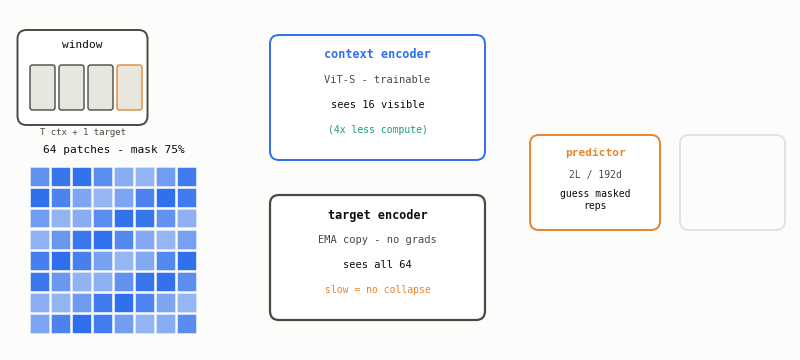

Fresh run: cleared /mnt/cluster_storage/ray_train_runs/jepa_world_model
Building pre-training dataset (50 episodes)...
Starting Phase 1: Distributed V-JEPA pre-training...


(TrainController pid=153553) [State Transition] INITIALIZING -> SCHEDULING.
(TrainController pid=153553) Attempting to start training worker group of size 4 with the following resources: [{'GPU': 1}] * 4
(RayTrainWorker pid=187226, ip=10.0.237.165) Setting up process group for: env:// [rank=0, world_size=4]
(TrainController pid=153553) Started training worker group of size 4: 
(TrainController pid=153553) - (ip=10.0.237.165, pid=187226) world_rank=0, local_rank=0, node_rank=0
(TrainController pid=153553) - (ip=10.0.237.165, pid=187228) world_rank=1, local_rank=1, node_rank=0
(TrainController pid=153553) - (ip=10.0.237.165, pid=187227) world_rank=2, local_rank=2, node_rank=0
(TrainController pid=153553) - (ip=10.0.237.165, pid=187229) world_rank=3, local_rank=3, node_rank=0
(TrainController pid=153553) [State Transition] SCHEDULING -> RUNNING.
(RayTrainWorker pid=187226, ip=10.0.237.165) /tmp/ipykernel_153157/3804289186.py:56: UserWarning: enable_nested_tensor is True, but self.use_nest


Phase 1 complete in 76.1s
Final metrics: {'epoch': 1, 'loss': 0.17556099593639374, 'epoch_time_s': 21.6, 'num_batches': 127}


In [9]:
from tools.viz import show_gif
show_gif("assets/nb04_cell9.gif",
         caption="inside one V-JEPA step: mask 75% -> context encoder (visible only) vs EMA target (all) -> predict in latent space; then: the same step on 2 DDP workers for 2 epochs -> checkpoint")
         
# Ray Train restores a run of the same name from STORAGE_PATH, so without this
# an earlier session's checkpoints decide what happens below. Clearing first
# makes every run of this notebook take the same path. Set FRESH_RUN = False to
# resume an interrupted run instead.
FRESH_RUN = True
if FRESH_RUN:
    import shutil
    shutil.rmtree(STORAGE_PATH, ignore_errors=True)
    print(f"Fresh run: cleared {STORAGE_PATH}")

print(f"Building pre-training dataset ({NUM_PRETRAIN_EPISODES} episodes)...")
train_ds = build_dataset(LOCAL_PRETRAIN_DIR)

trainer = TorchTrainer(
    train_loop_per_worker=train_loop_per_worker,
    train_loop_config={
        "num_epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "lr": LR,
    },
    scaling_config=ScalingConfig(
        num_workers=NUM_TRAIN_WORKERS,
        use_gpu=True,
    ),
    run_config=RunConfig(
        name="jepa-world-model",
        storage_path=STORAGE_PATH,
        failure_config=FailureConfig(max_failures=1),
    ),
    datasets={"train": train_ds},
)

print("Starting Phase 1: Distributed V-JEPA pre-training...")
t0 = time.time()
result = trainer.fit()
elapsed = time.time() - t0

print(f"\nPhase 1 complete in {elapsed:.1f}s")
print(f"Final metrics: {result.metrics}")

## Cell 10: Inspect Phase 1 results

Check that the V-JEPA pre-training loss decreased. Exact values will vary depending on data shuffling, masking randomness, and GPU timing.

Since this is an infrastructure tutorial, the goal is not state-of-the-art representations, but rather demonstrating that the V-JEPA training pipeline (streaming data, distributed training, EMA updates, checkpointing) works correctly and efficiently.

In [10]:
df = result.metrics_dataframe
print("Phase 1 training metrics:")
print(df[["epoch", "loss", "epoch_time_s", "num_batches"]].to_string(index=False))

Phase 1 training metrics:
 epoch     loss  epoch_time_s  num_batches
     0 0.440420          33.5          127
     1 0.206345          21.7          128


(TrainController pid=153553) [State Transition] SHUTTING_DOWN -> FINISHED.


Phase 1 training metrics:
 epoch     loss  epoch_time_s  num_batches
     0 0.409255          33.8          128
     1 0.175561          21.6          127


## Cell 11: Phase 2: Distributed online adaptation

This is the **world model payoff**. The pre-trained V-JEPA model encounters held-out episodes it has **never seen** during pre-training. Two DDP workers adapt the model in parallel, each processing its own shard of the new data. This is the pattern that matters for production robotics: a model that improves continuously from real-world experience, not just from its initial training set.

The adaptation loop on each worker:

1. **Loads the Phase 1 checkpoint** via `train.get_checkpoint()`. This is the same `run_name` and `storage_path` as Phase 1, so Ray Train finds the checkpoint automatically on Anyscale's shared storage
2. **Wraps the model with DDP** via `prepare_model()` for distributed gradient synchronization
3. **For each batch** from the held-out data:
   - **Predict** (eval mode, no grad): Run the model, measure prediction error *before* any update
   - **Update** (train mode, with grad): Forward pass, MSE loss, backward, optimizer step, EMA update. This is the continual learning step
   - **Measure** (eval mode, no grad): Run the model again, measure prediction error *after* the update
4. **Aggregates metrics** across workers via `all_reduce`

**The Ray Train pattern:** Notice that Phase 2 uses the **same `TorchTrainer` API** as Phase 1: same `ScalingConfig`, same `RunConfig`, same `datasets` interface. The only differences are the training function, the data source, and the learning rate. This is the key Ray Train value proposition: one API for pre-training, fine-tuning, adaptation, and evaluation. This same pattern works regardless of the world model architecture. If you swap V-JEPA for a diffusion-based model or an autoregressive predictor, the infrastructure code stays the same.

**The scaling story:** In production on Anyscale, a fleet of robots collects data from diverse environments. Each GPU worker receives data from a different environment and adapts the world model on its shard in parallel. DDP synchronizes the updates so the model improves from all environments simultaneously. This is exactly the pattern that `TorchTrainer` demonstrates. Scale to a full fleet by increasing `num_workers` on Anyscale.

**Why a lower learning rate?** `ADAPT_LR = 3e-5` (vs `LR = 1e-4` for pre-training). Online adaptation should make small, cautious updates. The pre-trained representations are valuable and you don't want to destabilize them with aggressive gradient steps.

In [11]:
print("\n" + "=" * 60)
print("Phase 2: Online Adaptation on Held-Out Episodes")
print("=" * 60)

# Get the best checkpoint from Phase 1
best_ckpt = result.get_best_checkpoint(metric="loss", mode="min")
if best_ckpt is None:
    best_ckpt = result.checkpoint
print(f"Phase 1 checkpoint: {best_ckpt}")


def adapt_loop_per_worker(config: dict):
    """Distributed online adaptation: predict → observe → update.

    Each DDP worker processes its shard of new data in parallel, simulating
    a robot fleet where each GPU adapts the world model on data from a
    different environment. Gradients are synchronized across workers via DDP.
    """
    device = torch.device("cuda")
    lr = config["adapt_lr"]

    # ── Model + DDP (distributed across workers) ──
    model = MultiCameraVJEPA().to(device)

    # ── Load pretrained checkpoint (same pattern as fault-tolerance resume) ──
    ckpt = train.get_checkpoint()
    state = None
    if ckpt:
        with ckpt.as_directory() as ckpt_dir:
            state_path = os.path.join(ckpt_dir, "state.pkl")
            if os.path.exists(state_path):
                with open(state_path, "rb") as f:
                    state = pickle.load(f)
    if state is not None:
        model.load_state_dict(state["model"])
        print(f"Loaded pretrained checkpoint from epoch {state['epoch']}")
    else:
        print("WARNING: No pre-training checkpoint found, starting from scratch")

    model = prepare_model(model)

    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,
    )
    scaler = torch.amp.GradScaler("cuda")

    model.train()
    shard = train.get_dataset_shard("train")

    errors_before = []
    errors_after = []
    window_idx = 0

    for batch in shard.iter_torch_batches(batch_size=BATCH_SIZE, device=device):
        # Skip padding rows
        if _SENTINEL_KEY in batch:
            mask = batch[_SENTINEL_KEY] == 0
            if not mask.any():
                continue
            if not mask.all():
                batch = {k: v[mask] for k, v in batch.items()}

        images = torch.stack([batch[k] for k in CAMERA_KEYS], dim=2)
        states = batch["states"]
        actions = batch["actions"]

        # ── Predict (before update) ──
        # Use eval mode so dropout is disabled, which gives a clean measurement
        # of prediction quality that is comparable to the "after" measurement.
        model.eval()
        with torch.no_grad(), torch.autocast("cuda", torch.float16):
            pred_before, target_before = model(images, states, actions)
            error_before = F.mse_loss(pred_before, target_before).item()
        errors_before.append(error_before)
        model.train()

        # ── Update: gradient step on prediction error ──
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast("cuda", torch.float16):
            pred, target = model(images, states, actions)
            loss = F.mse_loss(pred, target)

        old_scale = scaler.get_scale()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Only update the target encoder if the optimizer actually stepped
        if scaler.get_scale() >= old_scale:
            model.module.ema_update(EMA_MOMENTUM)

        # ── Measure (after update) ──
        model.eval()
        with torch.no_grad(), torch.autocast("cuda", torch.float16):
            pred_after, target_after = model(images, states, actions)
            error_after = F.mse_loss(pred_after, target_after).item()
        errors_after.append(error_after)
        model.train()

        window_idx += 1
        if window_idx % 100 == 0:
            avg_before = np.mean(errors_before[-100:])
            avg_after = np.mean(errors_after[-100:])
            print(f"  Window {window_idx}: avg error before={avg_before:.6f}, "
                  f"after={avg_after:.6f}")

    # ── Aggregate metrics across workers ──
    total_windows_t = torch.tensor([window_idx], device=device)
    error_sum_t = torch.tensor([sum(errors_before)], device=device)
    if dist.is_initialized():
        dist.all_reduce(total_windows_t)
        dist.all_reduce(error_sum_t)
    global_windows = total_windows_t.item()
    global_avg_error = (error_sum_t / total_windows_t.clamp(min=1)).item()

    initial_err = float(np.mean(errors_before[:50])) if len(errors_before) >= 50 else 0.0
    final_err = float(np.mean(errors_before[-50:])) if len(errors_before) >= 50 else 0.0
    error_change = (1 - final_err / initial_err) * 100 if initial_err > 0 else 0.0

    metrics = {
        "total_windows": global_windows,
        "global_avg_error": global_avg_error,
        "initial_error": initial_err,
        "final_error": final_err,
        "error_change_pct": round(error_change, 1),
    }

    ctx = train.get_context()
    if ctx.get_world_rank() == 0:
        print(f"\nAdaptation complete: {global_windows} windows across all workers")
        print(f"Global avg error: {global_avg_error:.6f}")
        print(f"Rank 0 initial error (first 50): {initial_err:.6f}")
        print(f"Rank 0 final error (last 50):    {final_err:.6f}")
        print(f"Rank 0 error change: {error_change:+.1f}%")

        # Save adaptation results from rank 0
        with tempfile.TemporaryDirectory() as d:
            with open(os.path.join(d, "adapt_results.pkl"), "wb") as f:
                pickle.dump({
                    "errors_before": errors_before,
                    "errors_after": errors_after,
                }, f)
            train.report(metrics, checkpoint=Checkpoint.from_directory(d))
    else:
        train.report(metrics)


# Build adaptation dataset and launch
print(f"Building adaptation dataset ({NUM_ADAPT_EPISODES} held-out episodes)...")
adapt_ds = build_dataset(LOCAL_ADAPT_DIR)

adapt_trainer = TorchTrainer(
    adapt_loop_per_worker,
    train_loop_config={"adapt_lr": ADAPT_LR},
    scaling_config=ScalingConfig(
        num_workers=NUM_TRAIN_WORKERS,
        use_gpu=True,
    ),
    run_config=RunConfig(
        # Use the SAME run name as Phase 1 so get_checkpoint() finds the
        # Phase 1 checkpoint automatically (standard Ray Train pattern).
        name="jepa-world-model",
        storage_path=STORAGE_PATH,
    ),
    datasets={"train": adapt_ds},
)

print(f"Starting Phase 2: Distributed online adaptation ({NUM_TRAIN_WORKERS} GPU workers)...")
t0 = time.time()
adapt_result = adapt_trainer.fit()
elapsed = time.time() - t0

print(f"\nPhase 2 complete in {elapsed:.1f}s")
print(f"Adaptation metrics: {adapt_result.metrics}")


Phase 2: Online Adaptation on Held-Out Episodes
Phase 1 checkpoint: Checkpoint(filesystem=local, path=/mnt/cluster_storage/ray_train_runs/jepa_world_model/jepa-world-model/checkpoint_2026-08-18_16-55-33.329844)
Building adaptation dataset (50 held-out episodes)...
Starting Phase 2: Distributed online adaptation (4 GPU workers)...


(TrainController pid=157522) A run snapshot was found in storage folder at: '/mnt/cluster_storage/ray_train_runs/jepa_world_model/jepa-world-model'
(TrainController pid=157522) This snapshot contains a list of checkpoints reported via `ray.train.report` and will be loaded. This allows the latest checkpoint found in the snapshot to be accessible within your training function via `ray.train.get_checkpoint`.
(TrainController pid=157522) If you meant to start a brand new training job without any information about previous checkpoints found in this directory, please configure a new, unique `RunConfig(name)` or delete the existing folder at '/mnt/cluster_storage/ray_train_runs/jepa_world_model/jepa-world-model'.
(TrainController pid=157522) [State Transition] INITIALIZING -> SCHEDULING.
(TrainController pid=157522) Attempting to start training worker group of size 4 with the following resources: [{'GPU': 1}] * 4
(RayTrainWorker pid=198449, ip=10.0.237.165) Setting up process group for: env:/

(SplitCoordinator pid=157757) Running Dataset: train_63_0. Active & requested resources: 0/48 CPU, 3.6GiB/43.2GiB object store: Progress Completed 2665 / 3959
(SplitCoordinator pid=157757) ReadLeRobot->SplitBlocks(4): Tasks: 0; Actors: 0; Queued blocks: 0 (0.0B); Resources: 0.0 CPU, 336.1MiB object store: Progress Completed 8934 / 8738
(SplitCoordinator pid=157757) MapBatches(build_temporal_windows): Tasks: 0; Actors: 0; Queued blocks: 0 (0.0B); Resources: 0.0 CPU, 5.1MiB object store: Progress Completed 3959 / 3937
(SplitCoordinator pid=157757) split(4, equal=True): Tasks: 0; Actors: 0; Queued blocks: 0 (0.0B); Resources: 0.0 CPU, 3.3GiB object store; [all objects local]: Progress Completed 3956 / 3959
(SplitCoordinator pid=157757) Running Dataset: train_63_0. Active & requested resources: 0/48 CPU, 3.6GiB/43.2GiB object store: Progress Completed 3556 / 3959
(SplitCoordinator pid=157757) ReadLeRobot->SplitBlocks(4): Tasks: 0; Actors: 0; Queued blocks: 0 (0.0B); Resources: 0.0 CPU, 336


Phase 2 complete in 57.1s
Adaptation metrics: {'total_windows': 496, 'global_avg_error': 0.12633439898490906, 'initial_error': 0.12557489171624184, 'final_error': 0.12289205834269523, 'error_change_pct': 2.1}


## Cell 12: Visualize adaptation

Load the adaptation error curves from the checkpoint saved by rank 0. Two plots:

1. **Running average of prediction error over time**: a downward trend confirms the model is learning from new observations. This is the "predict → observe → improve" loop in action.
2. **Before vs. after update scatter**: each point is one batch, with "before update" error on the x-axis and "after update" error on the y-axis. Points below the diagonal (y = x) mean the gradient step reduced prediction error on that batch. A cluster below the diagonal confirms that individual updates are beneficial, not just the long-run trend. 

(TrainController pid=157522) [State Transition] SHUTTING_DOWN -> FINISHED.


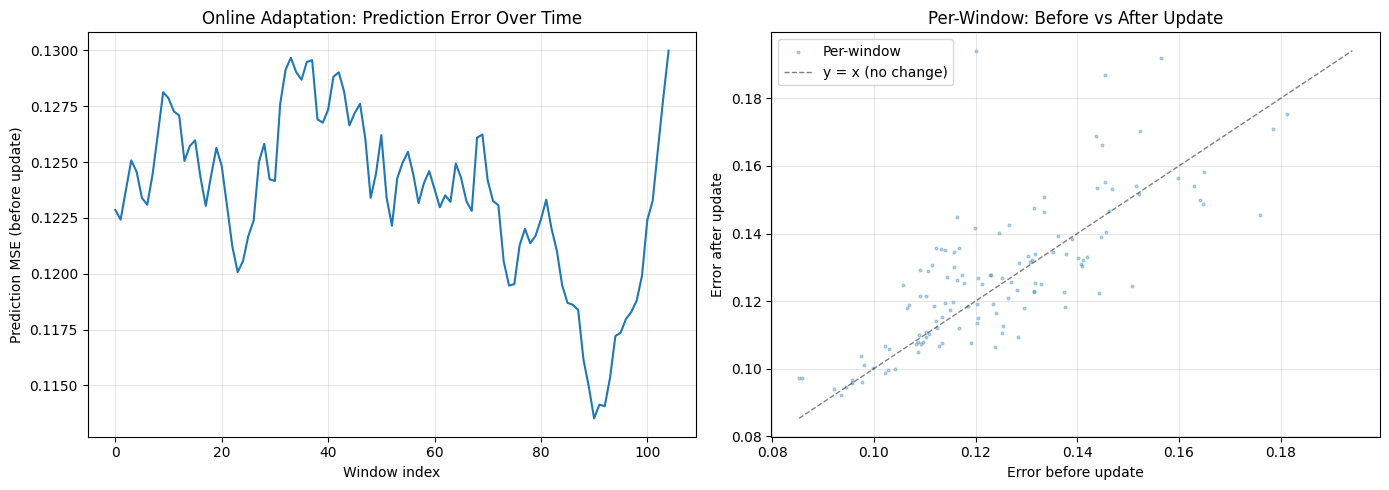

In [12]:
# Load adaptation results from checkpoint
adapt_ckpt = adapt_result.checkpoint
if adapt_ckpt:
    try:
        import matplotlib.pyplot as plt

        with adapt_ckpt.as_directory() as d:
            with open(os.path.join(d, "adapt_results.pkl"), "rb") as f:
                adapt_data = pickle.load(f)

        errors_before = adapt_data["errors_before"]
        errors_after = adapt_data["errors_after"]

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Plot 1: Running average of prediction error over time
        if len(errors_before) > 20:
            win = 20
            running_avg = np.convolve(
                errors_before, np.ones(win) / win, mode="valid"
            )
            axes[0].plot(running_avg, linewidth=1.5)
            axes[0].set_xlabel("Window index")
            axes[0].set_ylabel("Prediction MSE (before update)")
            axes[0].set_title("Online Adaptation: Prediction Error Over Time")
            axes[0].grid(True, alpha=0.3)

        # Plot 2: Before vs after scatter with y=x diagonal
        # Points below the diagonal mean the update helped.
        eb = np.array(errors_before)
        ea = np.array(errors_after)
        axes[1].scatter(eb, ea, s=4, alpha=0.3, label="Per-window")
        # Draw y=x reference line
        lo = min(eb.min(), ea.min())
        hi = max(eb.max(), ea.max())
        axes[1].plot([lo, hi], [lo, hi], "k--", linewidth=1, alpha=0.5,
                     label="y = x (no change)")
        axes[1].set_xlabel("Error before update")
        axes[1].set_ylabel("Error after update")
        axes[1].set_title("Per-Window: Before vs After Update")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
    except (ImportError, FileNotFoundError) as e:
        print(f"Skipping plot: {e}")

## Cell 13: Cleanup

Remove training checkpoints so the notebook can be rerun cleanly. The staged datasets are preserved to avoid redownloading from S3.

In [13]:
import shutil

# Clean training checkpoints so the notebook can be rerun cleanly.
# The staged datasets are preserved to avoid redownloading from S3.
shutil.rmtree(STORAGE_PATH, ignore_errors=True)
print(f"Removed training artifacts at {STORAGE_PATH}")

# Uncomment to also remove staged datasets:
# shutil.rmtree(LOCAL_PRETRAIN_DIR, ignore_errors=True)
# shutil.rmtree(LOCAL_ADAPT_DIR, ignore_errors=True)
# shutil.rmtree(LOCAL_FULL_DIR, ignore_errors=True)
# print("Removed staged datasets.")

print("Done.")

Removed training artifacts at /mnt/cluster_storage/ray_train_runs/jepa_world_model
Done.


(raylet) WARNING: 8 PYTHON worker processes have been started on node: e465b6828a135baca78afcfcb30a36818daea42d793776bcdfd4db9b with address: 10.0.210.111. This could be a result of using a large number of actors, or due to tasks blocked in ray.get() calls (see https://github.com/ray-project/ray/issues/3644 for some discussion of workarounds).


## Conclusion

In this notebook you built a complete world model training pipeline for robotics using **Ray on Anyscale**, with V-JEPA as the model architecture:

1. **Data staging on Anyscale**: Downloaded FMB from S3 to Anyscale's shared cluster storage (`/mnt/cluster_storage/`) and created separate pretrain/adaptation subsets, staged once and visible to all workers with no per-node duplication.
2. **Streaming data pipeline with Ray Data**: Used `read_lerobot` + `map_batches` to stream multi-camera video into temporal windows on CPUs, feeding preprocessed windows to GPUs via `iter_torch_batches`, with no full-dataset materialization.
3. **V-JEPA architecture**: ViT-Small context encoder, EMA target encoder, Transformer predictor with spacetime tube masking, action/state conditioning, and multi-camera weight sharing.
4. **Phase 1: Distributed pre-training with Ray Train**: `TorchTrainer` with DDP across every GPU in the cluster, FP16 mixed precision with GradScaler, EMA updates, checkpointing to shared storage, and fault tolerance via `FailureConfig`.
5. **Phase 2: Distributed online adaptation with Ray Train**: Loaded Phase 1 checkpoint via shared run name, adapted on held-out data across the same GPUs with the predict-observe-update loop, using the **same `TorchTrainer` API** as Phase 1.

### What Ray on Anyscale gave you

The V-JEPA model and training logic are pure PyTorch. What Ray on Anyscale handled:

- **Ray Data** decoupled CPU-bound video preprocessing from GPU-bound training, streaming data without memory bottlenecks
- **Ray Train** wrapped DDP with automatic dataset sharding, checkpoint management, and fault recovery. The training loop is a plain Python function, not a distributed systems exercise
- **Anyscale** provided the managed cluster, GPU scheduling, and shared filesystem, with no DevOps, no `scp`, and no `NCCL` debugging
- **Scaling requires config changes, not code changes:** move from 2 GPUs to 64 by updating `ScalingConfig(num_workers=N)`

### The infrastructure is architecture-agnostic

V-JEPA is one approach to world models, but the industry is actively exploring many others such as diffusion-based video prediction, autoregressive latent models, and architectures that haven't been published yet. The Ray on Anyscale patterns in this notebook don't depend on V-JEPA specifically:

- **Ray Data** streaming works for any model that consumes video; change the `map_batches` function to produce whatever tensors your architecture expects
- **Ray Train** `TorchTrainer` works for any PyTorch model; swap the training loop function, keep the `ScalingConfig`, `RunConfig`, and fault tolerance
- **The two-phase pattern** (pre-train → adapt) generalizes to any model with a checkpoint-and-continue workflow

If your team is building world models for robotics, whether based on V-JEPA, Genie, UniSim, DIAMOND, or a proprietary architecture, the infrastructure layer demonstrated here is the same.

### Next steps

- **Scale up on Anyscale**: Increase `NUM_PRETRAIN_EPISODES` to use the full FMB dataset (1804 episodes), scale to 8+ GPU workers with `ScalingConfig(num_workers=8)`, and train for more epochs with deeper ViT encoders. Same code, larger cluster.
- **Swap the architecture**: Replace V-JEPA with your own world model. The Ray Data pipeline, `TorchTrainer` setup, and checkpoint/adaptation patterns remain the same.
- **Downstream planning**: Use the learned world model representations for model-predictive control: predict future representations under candidate action sequences and select the best.
- **Combine with VLA**: Use world model representations as visual features for a Vision-Language-Action policy, replacing or augmenting frozen ImageNet features.
- **Multi-task fleet adaptation**: Deploy across a fleet of robots in different environments, each GPU worker adapting the shared model from its environment's data stream, the exact pattern `TorchTrainer` with `num_workers=N` demonstrates.
- **Cosine EMA schedule**: Implement the warmup schedule from $\tau = 0.996$ to $\tau = 1.0$ over training, used in production V-JEPA for more stable convergence.

---

Next, **`05_distillation_for_edge.ipynb`** closes the course. The VLA (notebook 02) and this world model (notebook 04) are powerful but far too large to run on a robot's onboard compute. You'll distill a large vision encoder into a small student backbone you could actually deploy -- scaling *down* to meet the other end of the lifecycle: **scale up to learn, scale down to deploy.**